## Setup

### Import Libraries

In [64]:
import torch
import torch.nn as nn

from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

### Utility Functions

In [82]:
def do_binary_classification(model, optimizer = torch.optim.RMSprop, loss_function = nn.BCEWithLogitsLoss(), epochs = 81):

    optimizer = optimizer(model.parameters(), lr = 0.1)

    # optimize model through iterative guessing and parameter updates
    for epoch in range(epochs):
        # reset gradients
        optimizer.zero_grad()

        # predict output with model
        y_pred = model(X)

        # calculate prediction loss
        loss = nn.BCEWithLogitsLoss()(y_pred.squeeze(), y.float())

        # do backpropagation to get gradients
        loss.backward()

        # update model parameters
        optimizer.step()

        if epoch % 20 == 0:
            print(f"epoch {epoch}, Loss: {loss.item():.4f}")
            probs = torch.sigmoid(y_pred)
            plt.figure()
            plt.title(f"\nepoch={epoch}, loss={loss:.4f}")
            plt.scatter(*X.T, s = 20, c = probs > 0.5, cmap='Set1');

class utils:
    do_binary_classification = do_binary_classification

### Generate Data

#### For Binary Classification

In [2]:
X_orig, y_orig = make_moons(256, noise=0.1, random_state=42)

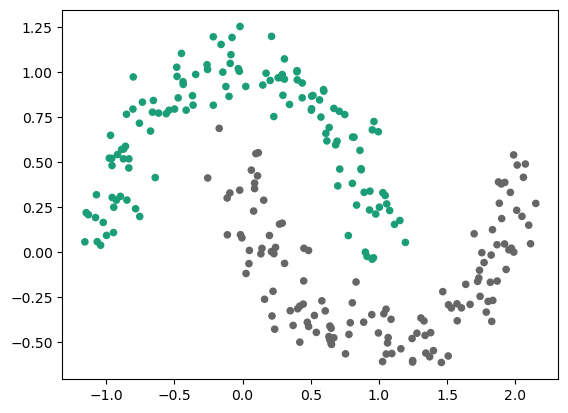

In [6]:
# This makes an independent copy (recommended in most cases)
X = torch.tensor(X_orig, dtype=torch.float32)
y = torch.tensor(y_orig, dtype=torch.long)


plt.scatter(*X.T, s = 20, c = y, cmap='Dark2');

## Section 1: Capturing Non-Linear Decision Boundaries

In the previous session, you did linear regression. Often, the relationship you want to uncover in your data isn't linear, in that case you need a model that can capture non-linear relationships. In this section, we'll see how that can be done.

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | A single layer that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `model(X_input)` | Pass input `X_input` to a neuronal network named `model`. |
| `y_model = model(X_input)` | Pass input `X_input` to a neuronal network `model` and assign the output to a variable `y_model`. |
| `nn.ReLU()` | Creates a rectified linear unit (ReLU) activation function.|
| `nn.Tanh()` | Creates hyperbolic tangent activation function.|
| `nn.Sigmoid()` | Creates a sigmoid activation function.|
| `nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(1,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;` nn.ReLU(),`<br>&nbsp;&nbsp;&nbsp;` nn.Linear(10,1)`<br>`)` | Creates a container where layers and activation functions are stacked in a sequential order. This ensures that the input is passed through the network in that order.|

**Exercise**: Create a linear model (like the one we used in the previous session) with 2 input features and 1 output feature. Pass this model as input to the function `utils.do_binary_classification`. Is this model able to do the classification correctly?

Step 0, Loss: 0.6880
Step 20, Loss: 0.2792
Step 40, Loss: 0.2702
Step 60, Loss: 0.2682
Step 80, Loss: 0.2676


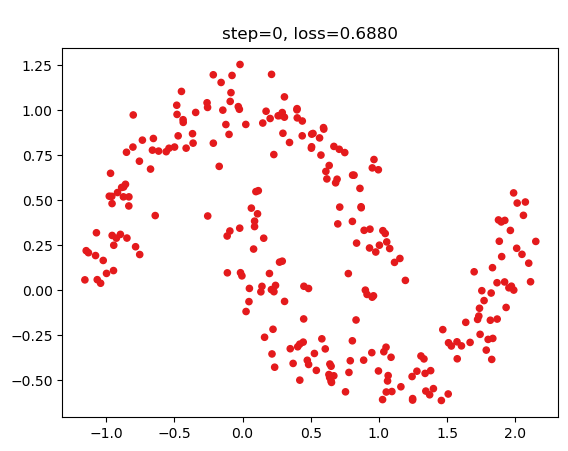

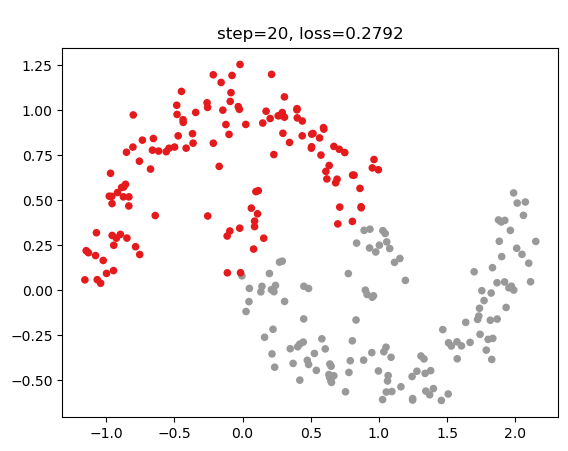

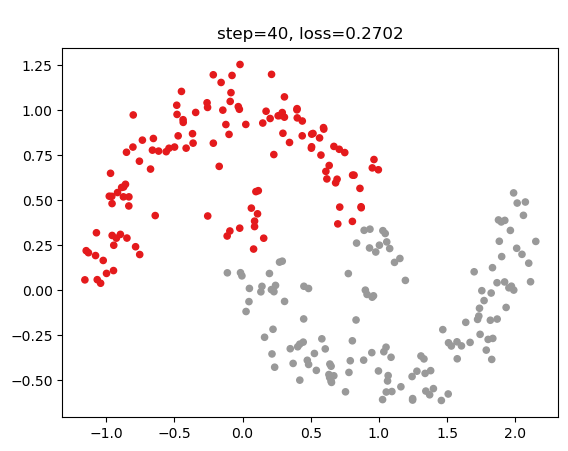

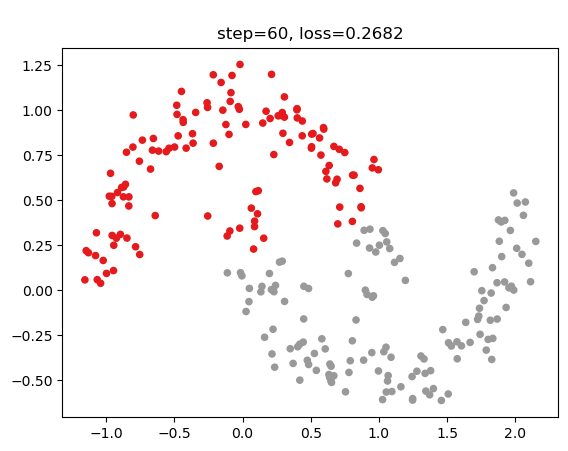

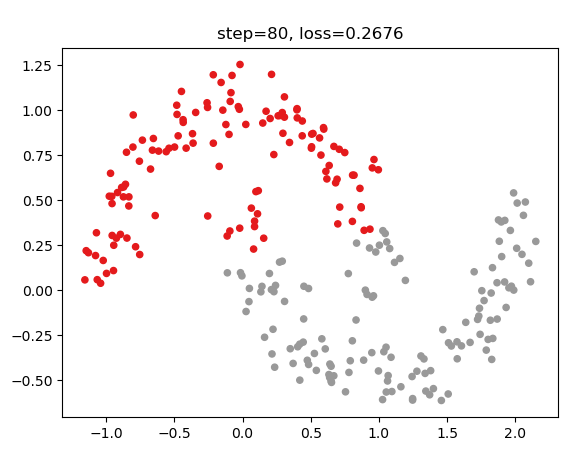

In [79]:
# create model
model = nn.Linear(2,1)

utils.do_binary_classification(model)

**Exercise**: Use the same model to do binary classification but this time, try increasing the number of epochs (no need to go beyond 200). Is the model able to do the classification correctly now?

epoch 0, Loss: 0.7399
epoch 20, Loss: 0.2852
epoch 40, Loss: 0.2718


epoch 60, Loss: 0.2687
epoch 80, Loss: 0.2678
epoch 100, Loss: 0.2675
epoch 120, Loss: 0.2675
epoch 140, Loss: 0.2674
epoch 160, Loss: 0.2674
epoch 180, Loss: 0.2674


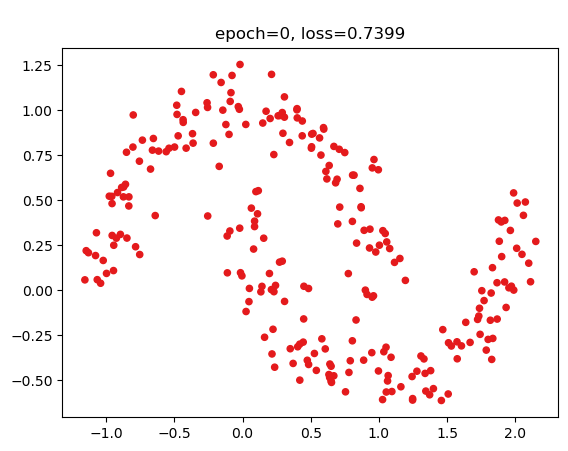

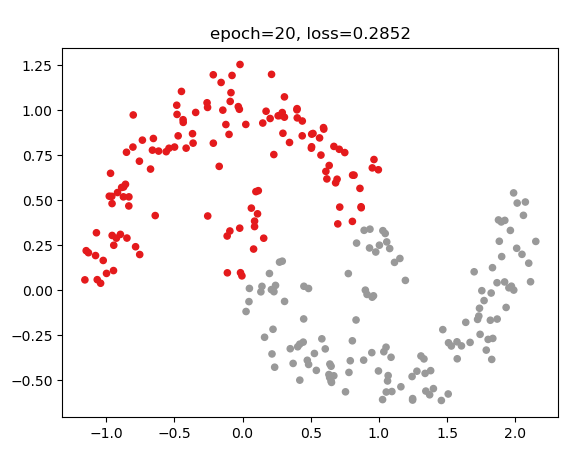

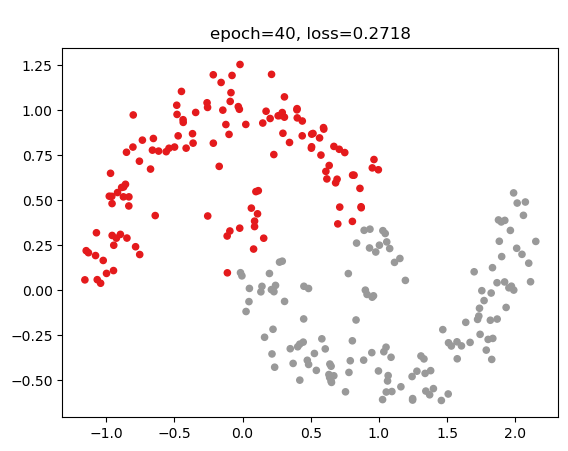

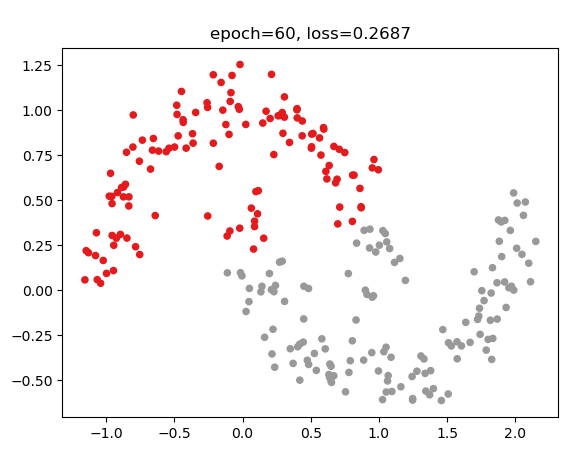

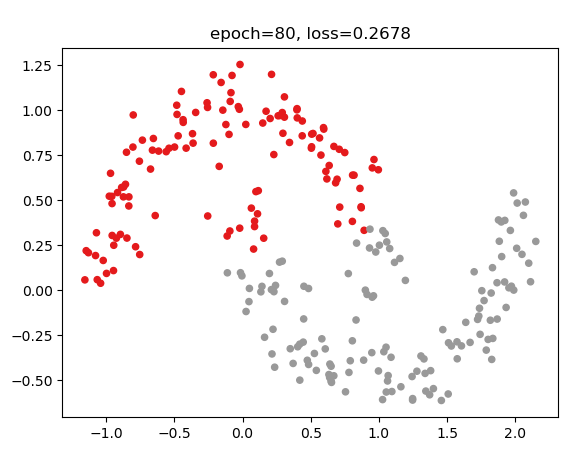

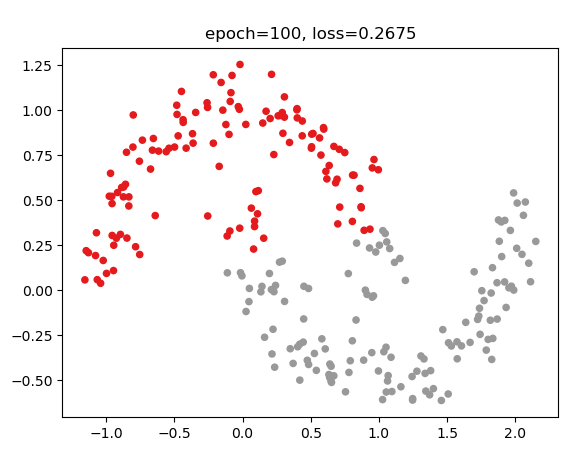

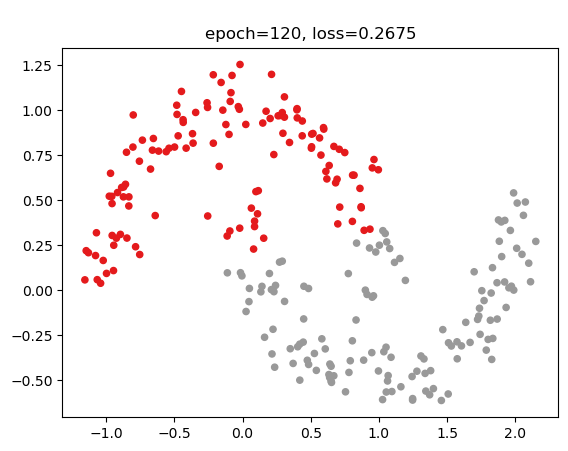

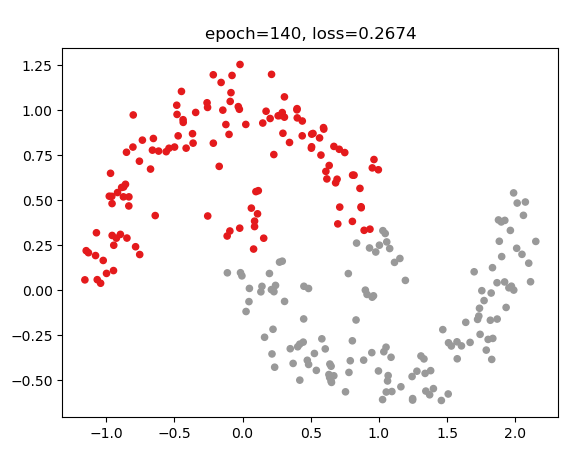

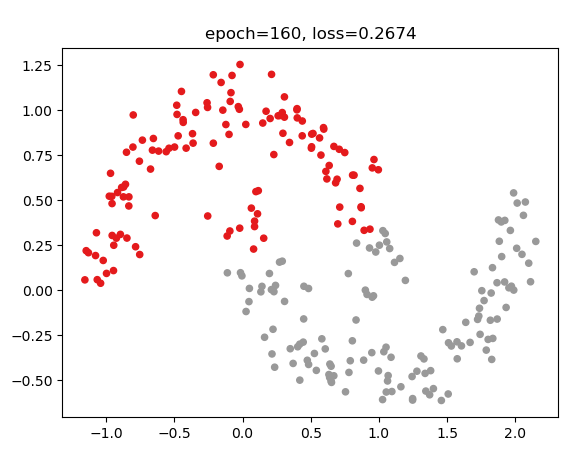

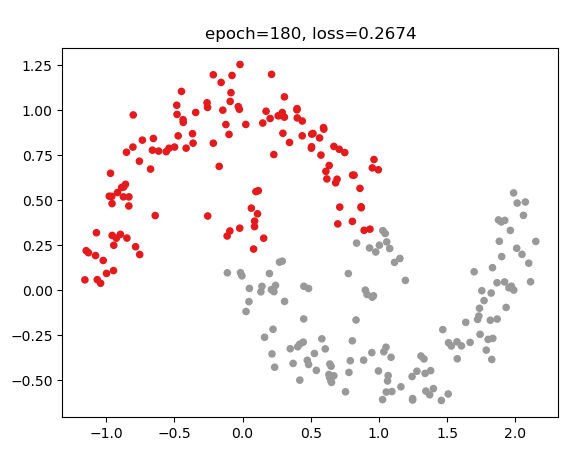

In [83]:
# create model
model = nn.Linear(2,1)

utils.do_binary_classification(model, epochs=200)

Even if the result might have improved a little bit, the linear model isn't able to do the classification correctly for all points, no matter how many epochs we train the model for. The reason is that this is a *non-linaer* problem, and a linear model will not be able to capture the non-linearities in the data. The way this has been solved for neural networks, is to add an *activation function* to the model.

**Example**: Create a model composed of two layers with a *rectified linear* unit between them. The first layer has two input features and one 16 output features, the last layer has 16 input features and 1 output feature. Pass the model to the utility function `utils.do_binary_classification`. Is the model able to correctly classify the points now?

epoch 0, Loss: 0.6317
epoch 20, Loss: 0.2380
epoch 40, Loss: 0.2081
epoch 60, Loss: 0.1140
epoch 80, Loss: 0.0437


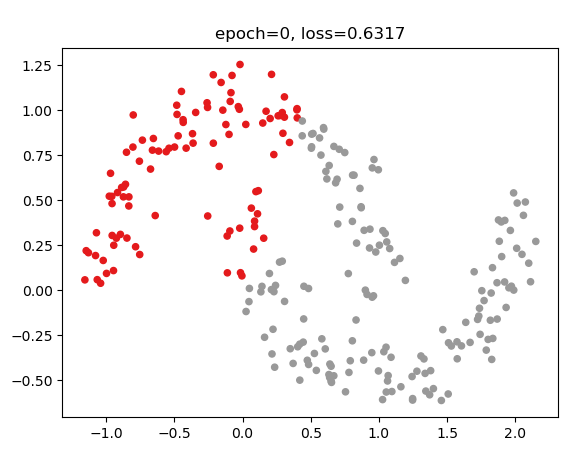

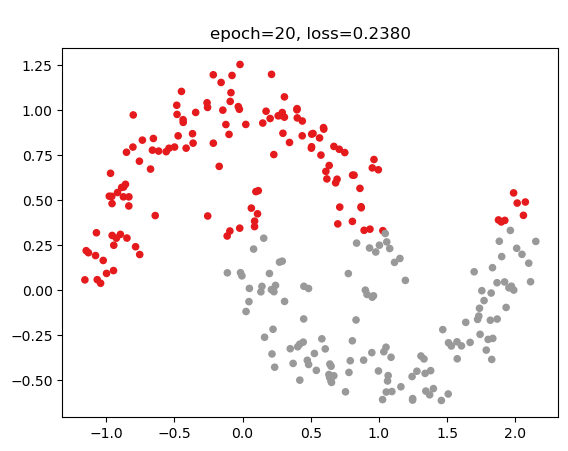

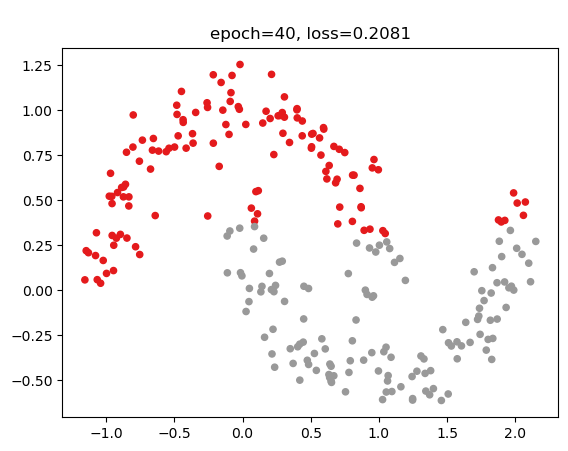

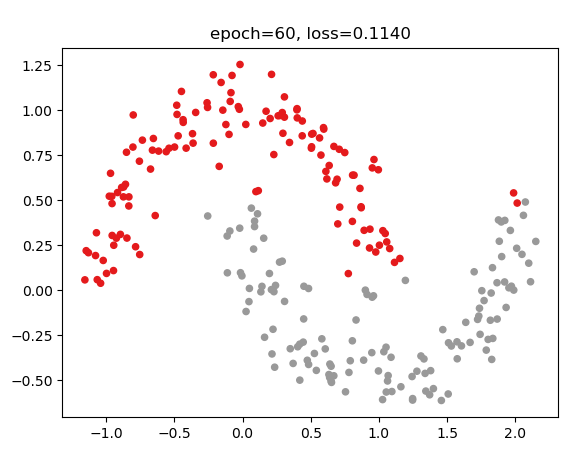

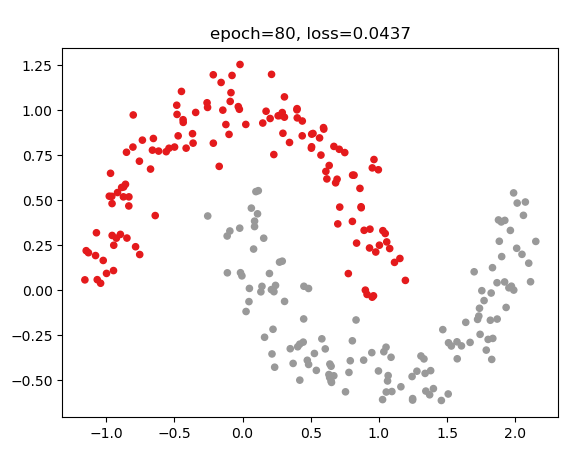

In [84]:
# create model
model = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,1)
)

utils.do_binary_classification(model)

There are different kinds of activation functions. Let's take a look at what some of the most common ones actually do.

**Exercise**: Create a rectified linear unit (ReLU) activation function and assign it to a variable called `activation_function`.

In [109]:
activation_function = nn.ReLU()
activation_function

ReLU()

**Exercise**: Pass the random input generated below to the ReLU activation function you just created and print the result. Compare the output to the random input. What happens to the negative and what happens to the positive numbers in the input?

In [103]:
torch.manual_seed(2025)
input = torch.randn(20)
input

tensor([-1.1607, -1.5591,  0.7782, -0.9990,  0.4670,  1.1802,  0.3709, -2.0193,
        -1.1871, -0.2822, -0.2651,  2.7671, -1.1414,  0.3533, -0.0972, -0.1674,
         0.9320, -0.7882, -2.8070,  0.5447])

In [104]:
activation_function(input)

tensor([0.0000, 0.0000, 0.7782, 0.0000, 0.4670, 1.1802, 0.3709, 0.0000, 0.0000,
        0.0000, 0.0000, 2.7671, 0.0000, 0.3533, 0.0000, 0.0000, 0.9320, 0.0000,
        0.0000, 0.5447])

**Demo**: Run the cell below to see a plot of the original input and the output from the activation function together. This visualizes the effect of the ReLU.

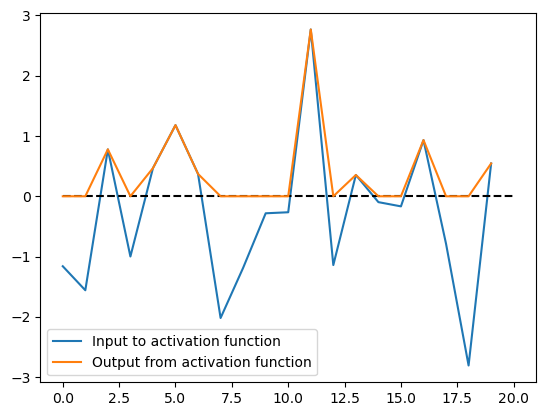

In [107]:
plt.plot(np.arange(len(input)), input, label = 'Input to activation function')
plt.hlines(xmin=0, xmax=len(input), y=0, ls='--', colors='k')
plt.plot(np.arange(len(input)), activation_function(input), label ='Output from activation function')
plt.legend()

**Exercise**: Create a hyperbolic tangent activation function and assign it to a variable named `activation_function`.

In [110]:
activation_function = nn.Tanh()
activation_function

Tanh()

**Exercise**: Pass the random input generated below to the hyperbolic tangent activation function you just created and print the result. Compare the output to the random input. What happens to the negative and what happens to the positive numbers in the input? (You can also use the visualization in the demo below to assess this.)

In [114]:
torch.manual_seed(2025)
input = torch.randn(20)
input

tensor([-1.1607, -1.5591,  0.7782, -0.9990,  0.4670,  1.1802,  0.3709, -2.0193,
        -1.1871, -0.2822, -0.2651,  2.7671, -1.1414,  0.3533, -0.0972, -0.1674,
         0.9320, -0.7882, -2.8070,  0.5447])

In [115]:
activation_function(input)

tensor([-0.8213, -0.9153,  0.6517, -0.7612,  0.4358,  0.8275,  0.3548, -0.9654,
        -0.8297, -0.2749, -0.2591,  0.9921, -0.8149,  0.3393, -0.0969, -0.1659,
         0.7315, -0.6574, -0.9927,  0.4965])

**Demo**: Run the cell below to see a plot of the original input and the output from the activation function together. This visualizes the effect of the hyperbolic tangent activation function.

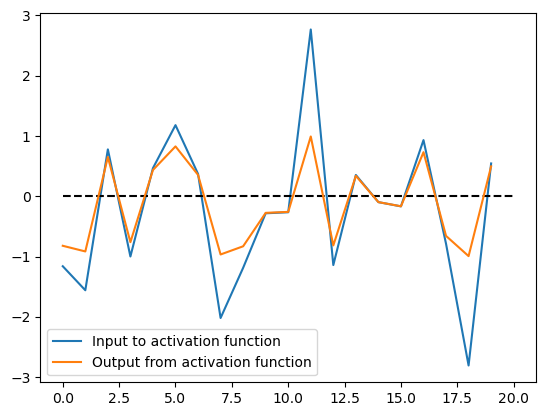

In [116]:
plt.plot(np.arange(len(input)), input, label = 'Input to activation function')
plt.hlines(xmin=0, xmax=len(input), y=0, ls='--', colors='k')
plt.plot(np.arange(len(input)), activation_function(input), label ='Output from activation function')
plt.legend()

**Exercise**: Create a sigmoid activation function and assign it to a variable named `activation_function`.

In [117]:
activation_function = nn.Sigmoid()
activation_function

Sigmoid()

**Exercise**: Pass the random input generated below to the hyperbolic tangent activation function you just created and print the result. Compare the output to the random input. What happens to the negative and what happens to the positive numbers in the input?

In [118]:
activation_function(input)

tensor([0.2385, 0.1738, 0.6853, 0.2691, 0.6147, 0.7650, 0.5917, 0.1172, 0.2338,
        0.4299, 0.4341, 0.9409, 0.2421, 0.5874, 0.4757, 0.4582, 0.7175, 0.3126,
        0.0569, 0.6329])

**Demo**: Run the cell below to see a plot of the original input and the output from the activation function together. This visualizes the effect of the sigmoid activation function.

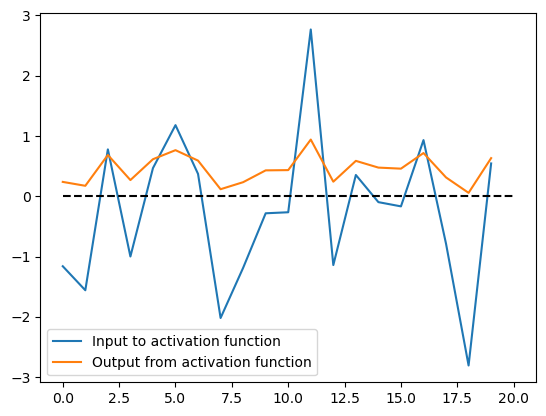

In [119]:
plt.plot(np.arange(len(input)), input, label = 'Input to activation function')
plt.hlines(xmin=0, xmax=len(input), y=0, ls='--', colors='k')
plt.plot(np.arange(len(input)), activation_function(input), label ='Output from activation function')
plt.legend()

Historically, the hyperbolic tangent activation function was used because it mimicked most closely the action of the axon hillock on a neuron. However, it was later shown that the rectified linear unit often produced better results (insert reference), and since then, it's been the most commonly used activation function in neural networks. Sigmoid activation functions are often used to convert the output of a network to probabilities between 0 and 1, which is particularly relevant for binary classification problems.

## Section 2: Create a sequence of layers.

**Exercise**: Create a sequence of layers with a rectified linear unit between them. The first layer should have two input features and 16 output features, the last layer should take in the 16 outputs from the first layer and output two features.
When you display it, the output should look like this:

Sequential(  <br>
  &nbsp;&nbsp;(0): Linear(in_features=2, out_features=16, bias=True)  <br>
  &nbsp;&nbsp;(1): ReLU()  <br>
  &nbsp;&nbsp;(2): Linear(in_features=16, out_features=2, bias=True)  <br>
)

**Hint**: nn.Sequential (see reference table).

In [ ]:
nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,2)
)

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=2, bias=True)
)

**Exercise**: Create sequence of three linear layers with one hyperbolic tangent activation function and one rectified linear unit between the first and the second linear layer, respectively. The first layer should have two input features and 32 output features, the next linear layer should have 32 input features and 32 output features, the last layer should take in the 32 outputs from the previous layer and output two features.
When you display it, the output should look like this:

Sequential(  <br>
  &nbsp;&nbsp;(0): Linear(in_features=2, out_features=32, bias=True)  <br>
  &nbsp;&nbsp;(1): Tanh()  <br>
  &nbsp;&nbsp;(0): Linear(in_features=32, out_features=32, bias=True)  <br>
  &nbsp;&nbsp;(1): ReLU()  <br>
  &nbsp;&nbsp;(2): Linear(in_features=32, out_features=2, bias=True)  <br>
)

**Hint**: nn.Sequential (see reference table).

In [71]:
nn.Sequential(
    nn.Linear(2,32),
    nn.Tanh(),
    nn.Linear(32,32),
    nn.ReLU(),
    nn.Linear(16,2)
)

Sequential(
  (0): Linear(in_features=2, out_features=32, bias=True)
  (1): Tanh()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=2, bias=True)
)

## Section 2: Binary Classification with a Neural Network Model 

| Code | Description |
| --- | --- |
| `` | duh |

In [47]:
model = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,1),
    nn.Sigmoid(),
)
model

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
  (3): Sigmoid()
)

In [51]:
model = nn.Linear(2,1)

from torch import optim

optimizer = optim.SGD(model.parameters(), lr=0.1)

for step in range(100):
    
#model(X)

tensor([[ 0.6682],
        [ 0.1559],
        [-1.0607],
        [ 0.5868],
        [-1.3583],
        [ 0.0815],
        [ 0.7628],
        [-0.1416],
        [ 0.0779],
        [-0.3356],
        [ 0.1035],
        [ 0.7149],
        [ 0.7640],
        [ 0.6464],
        [-0.7133],
        [-0.8407],
        [ 0.3247],
        [-0.1044],
        [-1.3692],
        [-0.1578],
        [ 0.7735],
        [-0.1965],
        [-1.1989],
        [-0.4393],
        [-0.1458],
        [-1.2295],
        [ 0.6936],
        [ 0.6552],
        [ 0.0485],
        [-0.1844],
        [ 0.1700],
        [-1.4058],
        [-0.3758],
        [ 0.3663],
        [ 0.6166],
        [-0.2199],
        [-1.2157],
        [-0.0671],
        [-0.9626],
        [-0.7099],
        [ 0.3959],
        [ 0.0550],
        [ 0.8584],
        [ 0.0831],
        [-0.6022],
        [-1.0724],
        [-0.1164],
        [-0.9620],
        [ 0.5771],
        [ 0.5931],
        [ 0.0646],
        [-0.3021],
        [-0.

tensor(0.5070, grad_fn=<MinBackward1>)

In [36]:
y_pred.squeeze()

tensor([1.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 9.9992e-01, 0.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 4.0617e-30, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 1.6430e-26, 4.3713e-38, 1.0000e+00,
        0.0000e+00, 2.5243e-21, 9.9970e-01, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 3.5419e-35,
        0.0000e+00, 1.2042e-03, 0.0000e+00, 1.6387e-32, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 2.0169e-33, 0.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0352e-31, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 1.0000e+00, 1.0952e-16, 1.0000e+00, 9.9972e-01,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 5.4670e-39, 1.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 1.7477e-

In [38]:
probs.shape

torch.Size([256, 1])

In [39]:
y_pred.shape

torch.Size([256, 2])

Step 0, Loss: 0.6428
Step 50, Loss: 0.0602


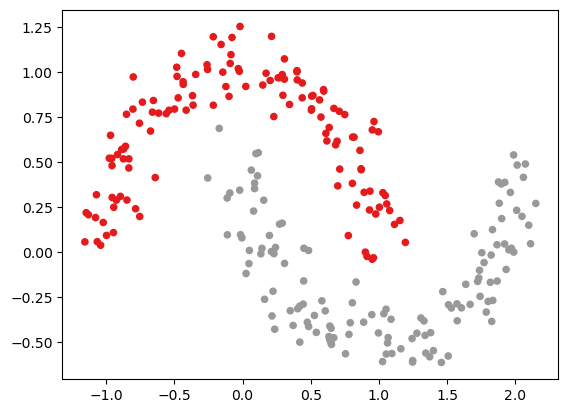

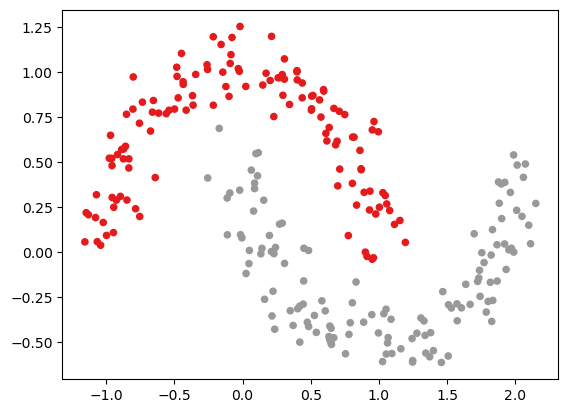

In [ ]:


from torch import optim

torch.manual_seed(42)

#model = nn.Linear(2, 1)  # linear regression

model = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,1)
)

optimizer = optim.RMSprop(model.parameters(), lr=0.1)  # Optimizer automatically updates parameters

for step in range(100):
    y_pred = model(X)  # forward pass (prediction)
    #loss = (y_pred - y).square().mean()  # error prediction (i.e. "loss")
    #loss = nn.CrossEntropyLoss()(y_pred, y)
    loss = nn.BCEWithLogitsLoss()(y_pred.squeeze(), y.float())
    optimizer.zero_grad()  # 
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print(f"Step {step}, Loss: {loss.item():.4f}")


probs = torch.sigmoid(y_pred)
plt.figure()
plt.scatter(*X.T, s = 20, c = probs > 0.5, cmap='Set1');
plt.figure()
plt.scatter(*X.T, s = 20, c = y_pred > 0, cmap='Set1');
#plt.scatter(*X.T, s = 20, c = torch.argmax(y_pred, dim=1), cmap='Set1');


The output of the network is a score for each class that reflects the networks belief that a data point corresponds to a given class. This is not the same as a class label. To get the output in the form of a class guess by the network, we have to determine which class the network thinks that a data point is most likely to belong to using the output scores.

| Code | Description |
| --- | --- |
| `torch.argmax(x, dim=1)` | Finds the index at which the tensor `x` has the highest value along its first dimension. |
| `a == b` | Compares each element of the tensors (or arrays) `a` and `b` and returns a tensor of boolean (`True` or `False`) values indicating which elements are the same (`True`) and different (`False`). |
| `(a == b).sum()` or `torch.sum(a == b)`| Sums all elements where the condition `a == b` is `True`. `True` is counted as 1, `False` as 0. |
| `(a == b).sum() / len(a)` | Calculates proportion of elements in `a` where the element is equal to the corresponding element in `b`.|

Run the cell below to create a network, select a subset of the data, and pass this subset through the network to get an output `y_net`.